In [4]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [2]:
%matplotlib widget


In [3]:
# ===================== Fovea Click Annotator =====================
import os, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Your existing helpers
from src.data.preprocessing import _iso_resize_and_pad
from src.retina_biomarkers.od_seg import (
    load_refuge_segformer, infer_label_map, extract_disc_mask_safe,
    center_and_pd_with_bounds
)

# Small cache so we only load the OD model once
class _ODHelper:
    def __init__(self):
        self.processor, self.model, self.device = load_refuge_segformer()

    def disc_info(self, rgb_iso, cup_dilate_frac=0.12, r_frac=(0.08, 0.16)):
        pred_map = infer_label_map(rgb_iso, self.processor, self.model, device=self.device)
        disc_mask = extract_disc_mask_safe(pred_map, self.model.config.id2label,
                                           img_shape=rgb_iso.shape,
                                           cup_dilate_frac=cup_dilate_frac)
        H, W = rgb_iso.shape[:2]
        center_yx, PD_raw, PD_px = center_and_pd_with_bounds(
            disc_mask, rgb_iso.shape, r_frac=r_frac,
            allow_fallback=True, fallback_center_yx=(H/2.0, W/2.0),
            fallback_PD_px=0.20 * min(H, W)
        )
        return disc_mask, tuple(map(float, center_yx)), float(PD_px)

def _draw_pd_rings(ax, center_yx, PD_px, *, max_PD=3.0, step_PD=0.5, color="cyan"):
    if center_yx is None or PD_px is None: return
    cy, cx = center_yx
    theta = np.linspace(0, 2*np.pi, 512)
    ax.scatter([cx], [cy], s=36, marker='x', color='yellow')
    for k in np.arange(step_PD, max_PD + 1e-9, step_PD):
        r = k * PD_px
        xx = cx + r*np.cos(theta); yy = cy + r*np.sin(theta)
        ax.plot(xx, yy, color=color, linewidth=1.2)
    # dashed 2-PD
    r = 2.0 * PD_px
    xx = cx + r*np.cos(theta); yy = cy + r*np.sin(theta)
    ax.plot(xx, yy, color=color, linestyle="--", linewidth=1.4)

def _ensure_df(csv_path: Path) -> pd.DataFrame:
    if csv_path.exists():
        try:
            return pd.read_csv(csv_path)
        except Exception:
            pass
    return pd.DataFrame(columns=["image_path", "H", "W", "fy", "fx", "disc_cy", "disc_cx", "PD_px", "ts"])

def _upsert_row(df: pd.DataFrame, row: dict, key="image_path") -> pd.DataFrame:
    m = (df[key] == row[key])
    if m.any():
        df.loc[m, list(row.keys())] = pd.Series(row)
    else:
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    return df

def annotate_fovea_for_images(
    image_paths,
    out_csv="fovea_points.csv",
    *,
    image_size=512,
    skip_if_present=True,
    cup_dilate_frac=0.12,
    r_frac=(0.08, 0.16)
):
    """
    Click once on each ISO-resized RGB image to mark the fovea.
    Saves a CSV with columns: image_path, H, W, fy, fx, disc_cy, disc_cx, PD_px, ts
    """
    out_csv = Path(out_csv)
    df = _ensure_df(out_csv)
    od = _ODHelper()  # load OD model once

    for img_path in image_paths:
        img_path = str(img_path)
        if skip_if_present and (df["image_path"] == img_path).any():
            print(f"✓ Skipping (already annotated): {img_path}")
            continue

        # Load & ISO-resize
        fundus = np.array(Image.open(img_path).convert("RGB"))
        rgb_iso = _iso_resize_and_pad(fundus, target=image_size, pad_value=0).astype(np.uint8)
        H, W = rgb_iso.shape[:2]

        # OD to help orientation drawing
        disc_mask, center_yx, PD_px = od.disc_info(rgb_iso, cup_dilate_frac=cup_dilate_frac, r_frac=r_frac)

        # Show
        fig, ax = plt.subplots(1, 1, figsize=(6.5, 6.5))
        ax.imshow(rgb_iso); ax.set_title("Click the FOVEA (press Esc to cancel)"); ax.axis("off")
        try:
            ax.contour(disc_mask.astype(bool), levels=[0.5], colors='y', linewidths=1.2)
        except Exception:
            pass
        _draw_pd_rings(ax, center_yx, PD_px, color="cyan")

        # Wait for a single click
        print(f"Click once to mark fovea for: {img_path}")
        pts = plt.ginput(1, timeout=0)  # 0 = no timeout
        plt.close(fig)

        if not pts:
            print(f"[warn] no point selected for: {img_path} (skipped)")
            continue

        fx, fy = pts[0]  # ginput returns (x, y)
        # Save row
        row = {
            "image_path": img_path,
            "H": H, "W": W,
            "fy": float(fy), "fx": float(fx),
            "disc_cy": float(center_yx[0]), "disc_cx": float(center_yx[1]),
            "PD_px": float(PD_px),
            "ts": int(time.time()),
        }
        df = _upsert_row(df, row)

        # Visual feedback
        print(f"Saved fovea: (fy={fy:.1f}, fx={fx:.1f})  PD={PD_px:.2f} px  -> {out_csv}")

    df.to_csv(out_csv, index=False)
    return out_csv

def load_fovea_lookup(csv_path="fovea_points.csv"):
    """Returns dict: {image_path: (fy, fx)} in ISO frame."""
    csv_path = Path(csv_path)
    if not csv_path.exists():
        return {}
    df = pd.read_csv(csv_path)
    lut = {}
    for _, r in df.iterrows():
        lut[str(r["image_path"])] = (float(r["fy"]), float(r["fx"]))
    return lut
# =================== end annotator ===================


KeyboardInterrupt: 

d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Click once to mark fovea for: ../../data/raw/DRIVE/test/images/01_test.png


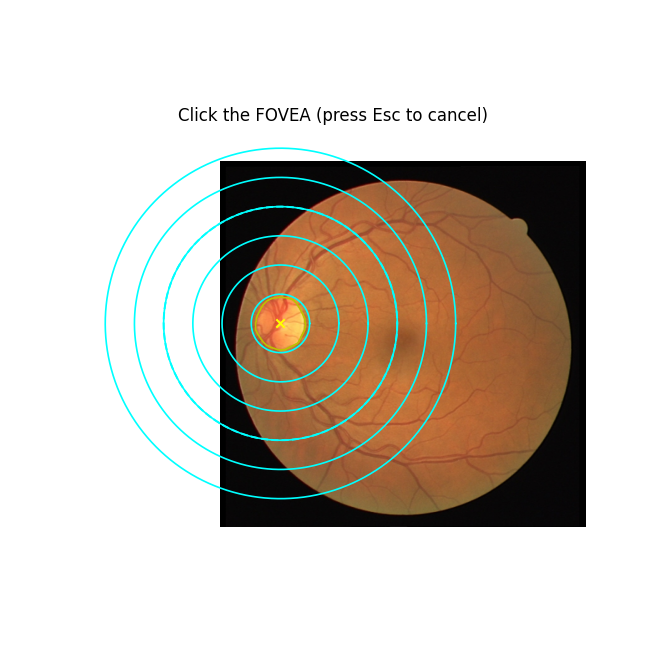

KeyboardInterrupt: 

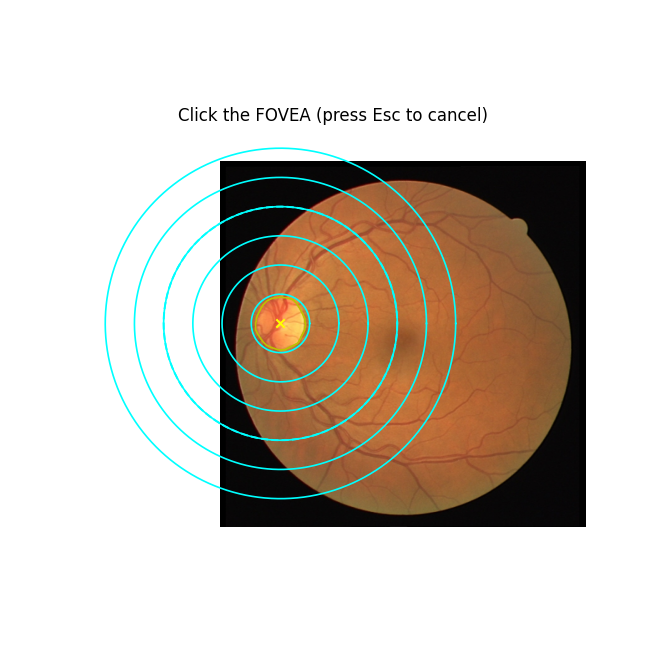

In [ ]:
# 1) Make sure clicks work in Jupyter:
%matplotlib widget

# 2) Pick the images you want to annotate
normal_paths = [
    "../../data/raw/DRIVE/test/images/01_test.png",
    "../../data/raw/DRIVE/test/images/10_test.png",
    "../../data/raw/DRIVE/test/images/13_test.png",
]
dr_paths = [
    "../../data/raw/DRIVE/test/images/08_test.png",
    "../../data/raw/DRIVE/test/images/14_test.png",
    "../../data/raw/DRIVE/test/images/17_test.png",
]
to_annotate = normal_paths + dr_paths

# 3) Click and save to CSV (skips previously annotated by default)
csv_file = annotate_fovea_for_images(to_annotate, out_csv="fovea_points.csv", image_size=512)

# 4) Load later and pass into your pipeline/quadrant logic
fovea_map = load_fovea_lookup(csv_file)
print(fovea_map.get(normal_paths[0]))  # -> (fy, fx) or None


In [5]:
%pip install -q ipympl
%matplotlib widget
%gui qt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# ===================== Matplotlib Fovea Click Annotator =====================
import time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from src.data.preprocessing import _iso_resize_and_pad  # adjust import if needed

def _ensure_df(csv_path: Path) -> pd.DataFrame:
    if csv_path.exists():
        try:
            return pd.read_csv(csv_path)
        except Exception:
            pass
    return pd.DataFrame(columns=["image_path","H","W","fy","fx","disc_cy","disc_cx","PD_px","ts"])

def _upsert_row(df: pd.DataFrame, row: dict, key="image_path") -> pd.DataFrame:
    m = (df[key] == row[key])
    if m.any():
        df.loc[m, list(row.keys())] = pd.Series(row)
    else:
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    return df

def annotate_fovea_mpl(
    image_paths,
    out_csv="fovea_points.csv",
    *,
    image_size=512,
    skip_if_present=True,
    confirm=True,              # press Enter to confirm; set False to save immediately on click
    dpi=140
):
    out_csv = Path(out_csv)
    df = _ensure_df(out_csv)

    for img_path in image_paths:
        img_path = str(img_path)
        if skip_if_present and (df["image_path"] == img_path).any():
            print(f"✓ Skipping (already annotated): {img_path}")
            continue

        # ISO-resize to your pipeline frame
        rgb = np.array(Image.open(img_path).convert("RGB"))
        rgb_iso = _iso_resize_and_pad(rgb, target=image_size, pad_value=0).astype(np.uint8)
        H, W = rgb_iso.shape[:2]

        fig, ax = plt.subplots(figsize=(6,6), dpi=dpi)
        ax.imshow(rgb_iso)
        ax.set_title("Click fovea • Enter=save • Backspace=clear • Esc=skip")
        ax.axis("off")

        marker = [None]
        point  = [None]

        def onclick(ev):
            if ev.inaxes is not ax or ev.xdata is None or ev.ydata is None:
                return
            x, y = ev.xdata, ev.ydata
            point[0] = (x, y)
            if marker[0]:
                marker[0].remove()
            marker[0] = ax.scatter([x],[y], s=80, marker="x")
            fig.canvas.draw_idle()
            if not confirm:
                plt.close(fig)

        def onkey(ev):
            if ev.key == "enter" and point[0] is not None:
                plt.close(fig)
            elif ev.key == "backspace":
                point[0] = None
                if marker[0]:
                    marker[0].remove()
                    marker[0] = None
                fig.canvas.draw_idle()
            elif ev.key == "escape":
                point[0] = None
                plt.close(fig)

        cid1 = fig.canvas.mpl_connect("button_press_event", onclick)
        cid2 = fig.canvas.mpl_connect("key_press_event", onkey)
        plt.show()

        if point[0] is None:
            print(f"[skip] no point for: {img_path}")
            continue

        fx, fy = map(float, point[0])
        row = {
            "image_path": img_path,
            "H": H, "W": W,
            "fy": fy, "fx": fx,
            "disc_cy": np.nan, "disc_cx": np.nan,
            "PD_px": np.nan,
            "ts": int(time.time()),
        }
        df = _upsert_row(df, row)
        df.to_csv(out_csv, index=False)
        print(f"Saved fovea for {Path(img_path).name}: (fy={fy:.1f}, fx={fx:.1f}) -> {out_csv}")

    return str(out_csv)

def load_fovea_lookup(csv_path="fovea_points.csv"):
    p = Path(csv_path)
    if not p.exists():
        return {}
    df = pd.read_csv(p)
    return {str(r["image_path"]): (float(r["fy"]), float(r["fx"])) for _, r in df.iterrows()}
# ===================== end =====================


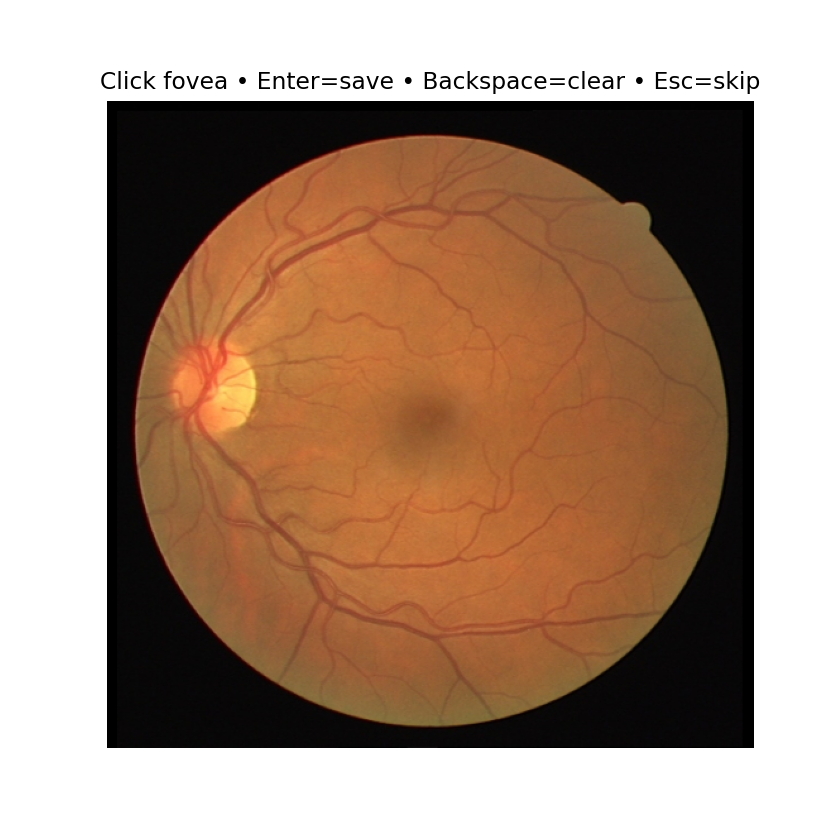

[skip] no point for: ../../data/raw/DRIVE/test/images/01_test.png


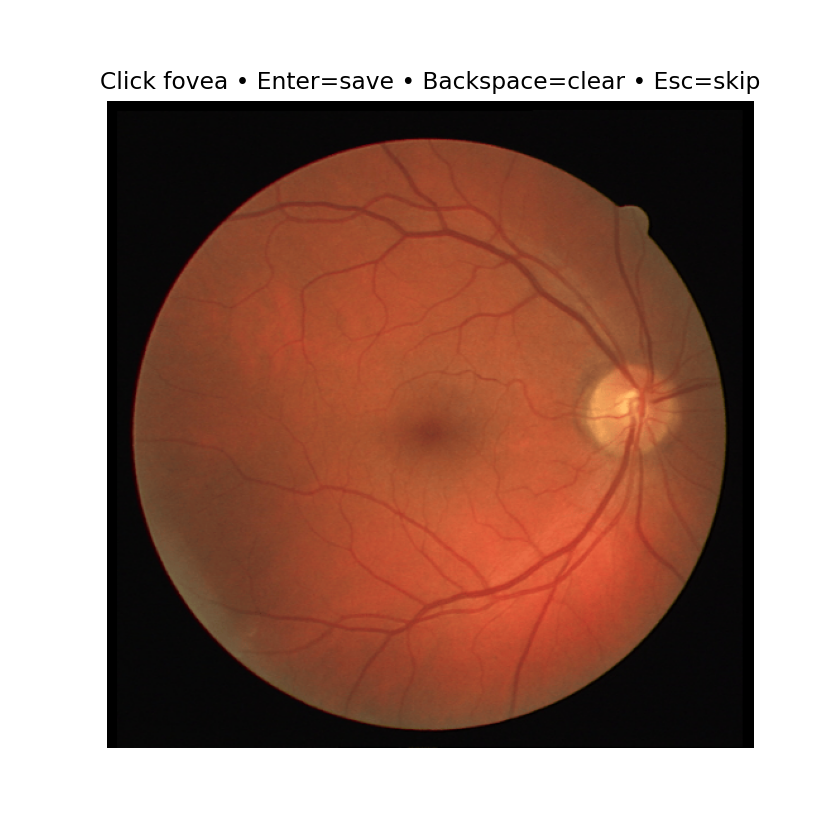

[skip] no point for: ../../data/raw/DRIVE/test/images/10_test.png


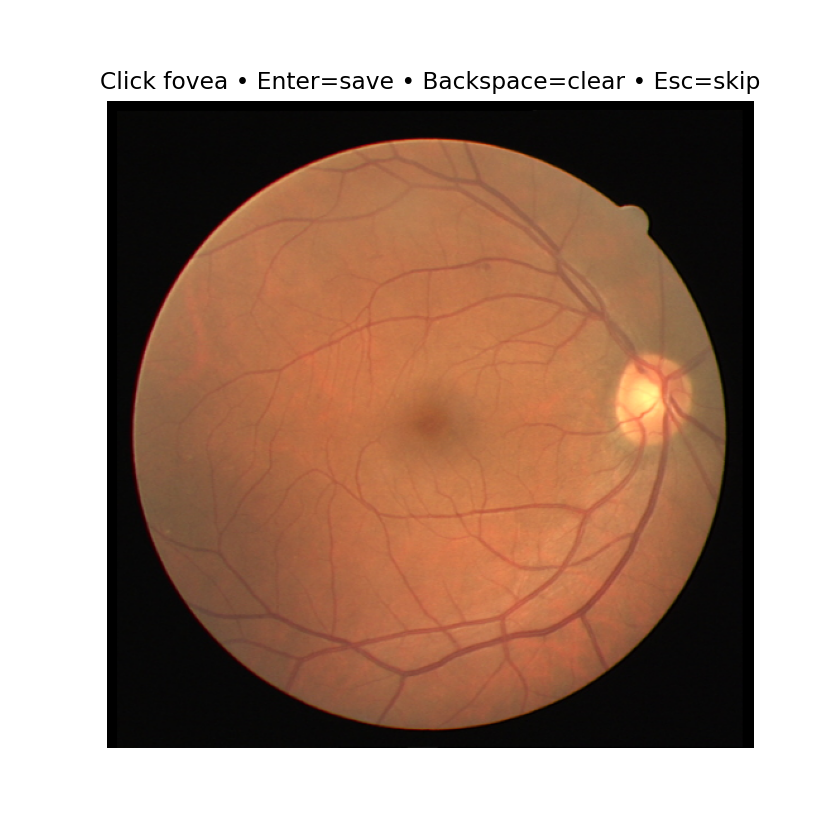

[skip] no point for: ../../data/raw/DRIVE/test/images/13_test.png


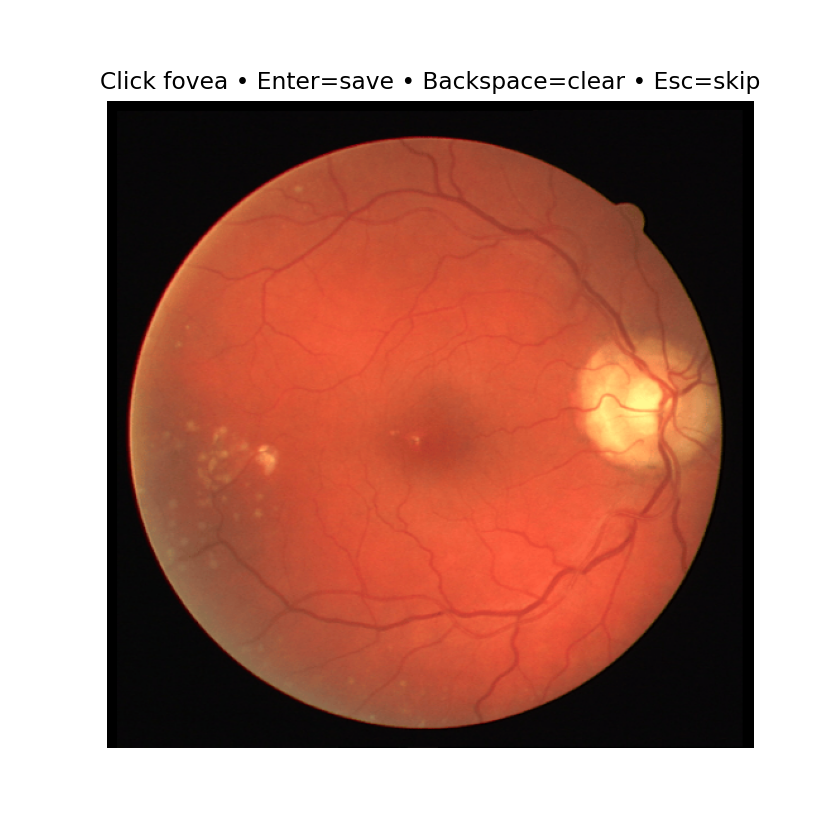

[skip] no point for: ../../data/raw/DRIVE/test/images/08_test.png


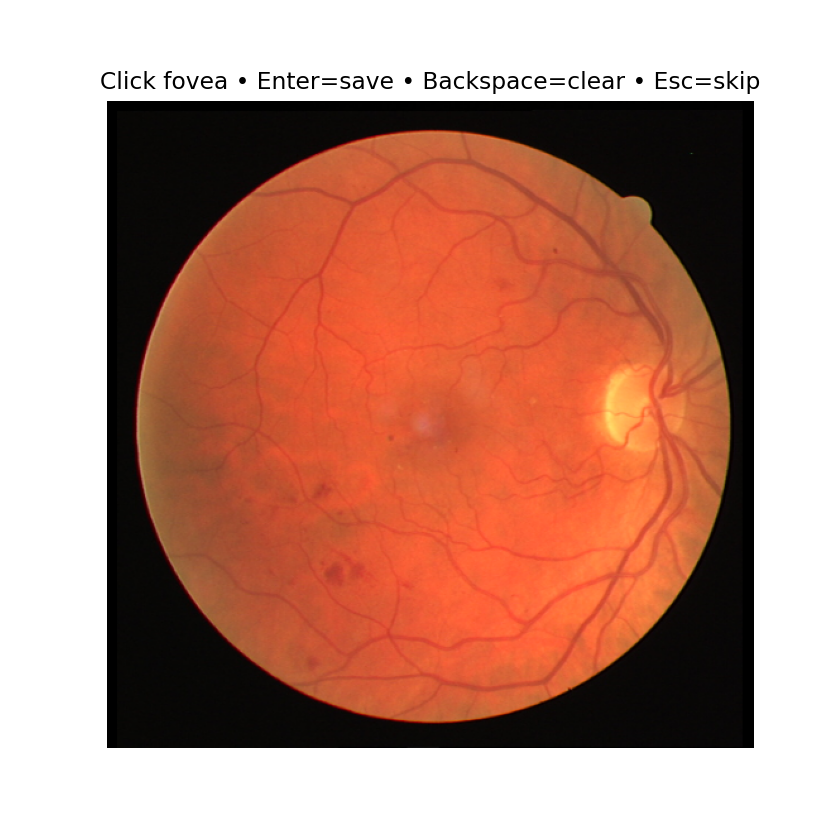

[skip] no point for: ../../data/raw/DRIVE/test/images/14_test.png


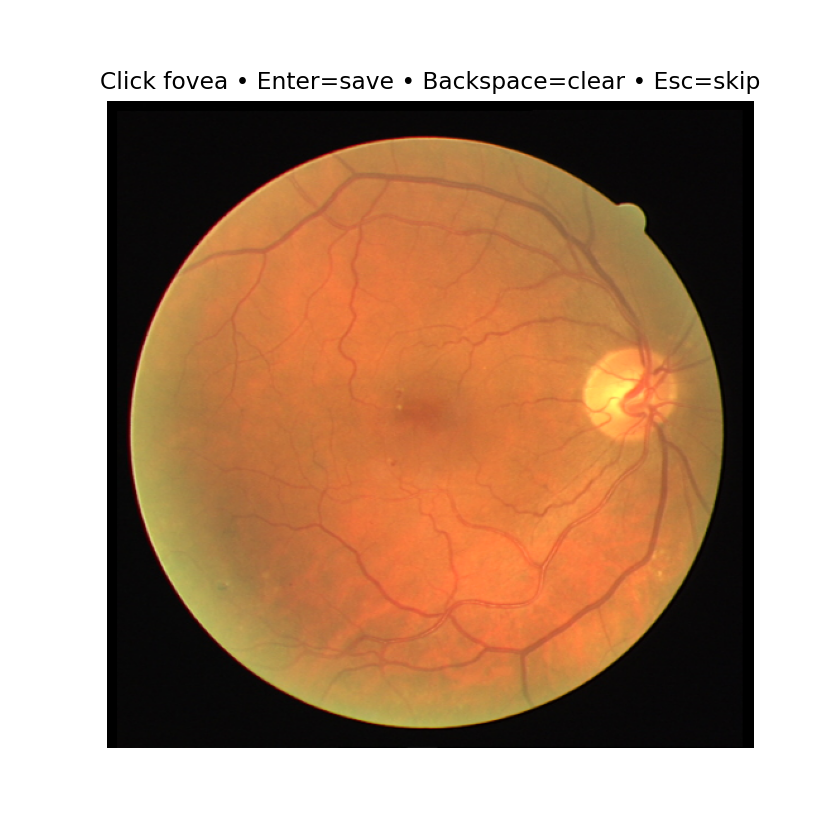

[skip] no point for: ../../data/raw/DRIVE/test/images/17_test.png
CSV saved at: fovea_points.csv


In [ ]:
normal_paths = [
    "../../data/raw/DRIVE/test/images/01_test.png",
    "../../data/raw/DRIVE/test/images/10_test.png",
    "../../data/raw/DRIVE/test/images/13_test.png",
]
bgdr_paths = [
    "../../data/raw/DRIVE/test/images/08_test.png",
    "../../data/raw/DRIVE/test/images/14_test.png",
    "../../data/raw/DRIVE/test/images/17_test.png",
]
pdr_paths = [
    "../../data/raw/DRIVE/test/images/04_test.png",
]
